In [165]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [166]:
directory = "E:/instagram_dataset_raws/Instagram influencer dataset/"

### Load influencers

In [167]:
import pandas as pd
import os

influencers = pd.read_csv(
    os.path.join(directory, "influencers.txt"),
    sep="\t",   # change to "," if needed
    header=None,
    names=["username", "category", "followers", "followees", "num_posts"]
)

influencers.head()


,username,category,followers,followees,num_posts
0,Username,Category,#Followers,#Followees,#Posts
1,==============================================...,NaN,NaN,NaN,NaN
2,makeupbynvs,beauty,1432,1089,363
3,jaquelinevandoski,beauty,137600,548,569
4,anisaartistry,beauty,64644,289,391


### Count how many influencers per category

In [168]:
influencers["category"].value_counts()


category
fashion        11911
other           5720
travel          4210
family          4070
food            3565
beauty          1542
interior        1195
fitness         1133
pet              587
Category           1
fasion             1
fashion 0.5        1
Name: count, dtype: int64

There are 33,935 influencers in 9 categories, and each influencer has 300 posts. Each post has metadata and image files. 
To reduce the data being used, I will do a random sample of 50 influencers from each category, and all 300 of their posts, resulting in 9x50x300=100k+ posts.
If this helps the performance, then I may increase the number of posts used from the dataset.

In [169]:
exclude_categories = [
    "Category",
    "fasion",
    "fashion 0.5"
]


In [170]:
N = 50

filtered_influencers = influencers[
    (~influencers["category"].isin(exclude_categories)) &
    (influencers["category"].notna())
].reset_index(drop=True)

sampled_influencers = (
    filtered_influencers
    .groupby("category", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(len(x), N),  # avoid errors if category is small
        random_state=42
    ))
    .reset_index(drop=True)
)


C:\Users\sugar\AppData\Local\Temp\ipykernel_55872\2679657196.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [171]:
sampled_influencers["category"].value_counts()


category
beauty      50
family      50
fashion     50
fitness     50
food        50
interior    50
other       50
pet         50
travel      50
Name: count, dtype: int64

### Build a set of valid usernames

In [172]:
valid_usernames = set(sampled_influencers["username"])


In [173]:
print(len(valid_usernames))

450


### Build mapping from metadata JSON to image files, filtering for only selected influencers

In [174]:
mapping_file = os.path.join(directory, "JSON-Image_files_mapping.txt")

In [175]:
# Search for exact username and post id
target_username = "maddchadd"
target_post_id = "814722363889295440"

with open(mapping_file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        if (
            line.startswith(target_username + "\t")
            and target_post_id in line
        ):
            print(f"Found at line {i}:")
            print(line)
            break
    else:
        print("No matching line found")

Found at line 5472020:
maddchadd	814722363889295440.info	['814722363889295440.jpg']



In [176]:
from collections import defaultdict
import ast

json_to_images = defaultdict(list)

with open(mapping_file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        parts = line.rstrip().split("\t")

        if len(parts) != 3:
            continue

        username, info_file, image_list_str = parts
        username = username.strip().lower()  # normalize
        if username not in valid_usernames:
            # print(f"excluded:{username}")
            continue

        # Safely parse "['img1.jpg', 'img2.jpg']"
        image_files = ast.literal_eval(image_list_str)

        # prepend username to filenames
        full_info_file = f"{username}-{info_file}"
        full_image_files = [f"{username}-{img}" for img in image_files]

        json_to_images[full_info_file].extend(full_image_files)

        if i % 500_000 == 0:
            print(f"Processed {i:,} lines")


Processed 6,000,000 lines


### Verify mapping completion

In [177]:
print("Valid usernames:", len(valid_usernames))
print("Posts kept:", len(json_to_images))
print("Total images:", sum(len(v) for v in json_to_images.values()))


Valid usernames: 450
Posts kept: 133060
Total images: 169477


In [178]:
len(json_to_images)

133060

In [179]:
next(iter(json_to_images.items()))

('21andhungry-1666253905100487663.info',
 ['21andhungry-1666253905100487663.jpg'])

### Whitelist of JSON filenames

In [180]:
json_files_to_load = set(json_to_images.keys())
len(json_files_to_load)

133060

In [181]:
next(iter(json_files_to_load))

'averystamm-1818984236164323655.info'

### Functions to extract image paths and find files

In [182]:
def find_all_images(folder_path):
    return sorted([
        os.path.join(folder_path, f)
        for f in os.listdir(folder_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ])

In [183]:
def find_file_by_ext(folder_path, extensions):
    """
    Returns the first file in folder_path matching any extension in extensions
    """
    for f in os.listdir(folder_path):
        if f.lower().endswith(extensions):
            return os.path.join(folder_path, f)
    return None

### Quick view of metadata contents

In [184]:
import json, gzip, lzma

def load_metadata(path):
    if path.endswith(".gz"):
        with gzip.open(path, "rt", encoding="utf-8") as f:
            return json.load(f)
    elif path.endswith(".xz"):
        with lzma.open(path, "rt", encoding="utf-8") as f:
            return json.load(f)

# Test loading of metadata with 1 sample
json_dir = os.path.join(directory, "Post_metadata/posts_info/info")
# json_file = next(iter(json_files_to_load))
json_files_to_load_list = list(json_files_to_load)
json_file = json_files_to_load_list[100] # random entry

meta_path = os.path.join(json_dir, json_file)
# meta = load_metadata(meta_path)
with open(meta_path, "r", encoding="utf-8") as f:
        meta = json.load(f)
print(meta.keys())
# print(meta['node'].keys())
for k, v in meta.items(): #['node'].items():
    print("KEY:", k)
    print("VALUE:", v)
    print("-" * 40)

dict_keys(['is_video', 'media_preview', 'viewer_in_photo_of_you', 'edge_media_preview_like', 'has_ranked_comments', 'display_url', 'owner', 'location', 'edge_web_media_to_related_media', 'caption_is_edited', 'edge_media_to_sponsor_user', 'taken_at_timestamp', 'edge_media_to_parent_comment', 'display_resources', 'viewer_has_saved_to_collection', 'dimensions', 'viewer_can_reshare', 'viewer_has_saved', 'gating_info', 'edge_media_to_tagged_user', 'is_ad', 'id', 'edge_media_preview_comment', '__typename', 'should_log_client_event', 'viewer_has_liked', 'edge_media_to_caption', 'tracking_token', 'edge_sidecar_to_children', 'shortcode', 'comments_disabled'])
KEY: is_video
VALUE: False
----------------------------------------
KEY: media_preview
VALUE: None
----------------------------------------
KEY: viewer_in_photo_of_you
VALUE: False
----------------------------------------
KEY: edge_media_preview_like
VALUE: {'count': 3404, 'edges': []}
----------------------------------------
KEY: has_rank

### Extract post metadata from limited influencers

In [190]:
import json
import os
from pathlib import Path
from datetime import datetime, timezone
from tqdm import tqdm
from langdetect import detect, LangDetectException


records = []
bad_json_count = 0

json_dir = os.path.join(directory, "Post_metadata/posts_info/info")
image_dir = os.path.join(directory, "Post_images/posts_image/image")

# order and find total number
json_files_to_load = sorted(json_to_images.keys())
total_files = len(json_files_to_load)

# loop with progress 
for json_file in tqdm(json_files_to_load, total=total_files, desc="Processing posts"):
    json_path = os.path.join(json_dir, json_file)
    # json_path = str(Path(json_path).as_posix()) # normalise the path to /
    # if not os.path.exists(json_path):
    #     # print(json_path)
    #     continue

    try:
        with open(json_path, "r", encoding="utf-8") as f:
            metadata = json.load(f)
    except (json.JSONDecodeError, OSError, UnicodeDecodeError):
        bad_json_count += 1
        continue

    # ====================
    # JSON extraction
    # ====================

    # --- Extract metadata from nested JSON ---
    # node = metadata.get('node', {})

    # --- Caption ---
    edges = metadata.get("edge_media_to_caption", {}).get("edges", [])
    if not edges:
        continue

    caption = edges[0].get("node", {}).get("text", "").strip()
    if not caption:
        continue

    # --- Language filter ---
    try:
        if detect(caption) != "en": # keep only english captions
            continue
    except LangDetectException:
        continue

    # === Owner metrics ===
    # followers = metadata.get("owner", {}).get("edge_followed_by", {}).get("count", 0) #### DONT HAVE
    # following = metadata.get("owner", {}).get("edge_follow", {}).get("count", 0) #### DONT HAVE, in influencers.txt
    owner = metadata.get("owner", {})
    user_id = owner.get("id", None)#.get("count", 0)
    username = owner.get("username", None)

    # === Post metrics ===
    # Timestamp (convert from UNIX epoch to readable)
    ts = metadata.get('taken_at_timestamp', None)
    if ts:
        publish_timestamp = datetime.fromtimestamp(ts, tz=timezone.utc).strftime('%Y-%m-%d %H:%M:%S')
    else:
        publish_timestamp = ''

    # Location
    has_location = 1 if metadata.get("location") else 0

    # # Flag carousel posts (> 1 image)
    # sidecar = metadata.get("edge_sidecar_to_children") #### DONT HAVE

    # is_carousel = (
    #     1 if sidecar and len(sidecar.get("edges", [])) > 0 else 0
    # )

    # # Get number of images in post
    # if sidecar and "edges" in sidecar:
    #     num_images = len(sidecar["edges"])
    # else:
    #     num_images = 1  # single-image post

    # Flag sponsored content
    sponsor_edge = metadata.get("edge_media_to_sponsor_user")

    is_sponsored = (
        1 if sponsor_edge and len(sponsor_edge.get("edges", [])) > 0 else 0
    )

    # === Engagement-related ===
    # likes = metadata.get("edge_media_preview_like", {}).get("count", 0)
    # comments = metadata.get("edge_media_preview_comment", {}).get("count", 0) ### NO 'TO_COMMENT', HAVE 'PREVIEW_COMMENT'
    preview_like = metadata.get("edge_media_preview_like", {})
    preview_comment = metadata.get("edge_media_preview_comment", {})

    likes = preview_like.get("count", 0)
    comments = preview_comment.get("count", 0)

    # Calculate engagement rate
    # engagement_rate = (likes + comments) / max(followers, 1) # avoid division by 0

    

    # --- Find Image / Video file ---
    # Filter out video posts for this project
    if metadata.get("is_video"):
        continue  # skip video posts

    # Find number of image files for post
    image_list = json_to_images.get(json_file, [])
    # Extract all images, save local relative path in list
    image_path = [
            os.path.join(image_dir, img)
            for img in image_list
        ]
    # images = find_all_images(image_dir)
    # images[0] if images else None

    
    # Flag carousel posts (>1 image)
    is_carousel = 1 if len(image_list) > 1 else 0
    # Count number of images in post
    num_images = len(image_list)


    if image_path is None:
        continue  # skip posts without images

    # ===============================
    records.append({
        # Owner metrics
        "user_id": user_id,
        "username": username,
        # "followers": followers, # in influencers.txt
        # "following": following, # in influencers.txt
        # Post metrics
        "publish_timestamp": publish_timestamp,
        "has_location": has_location,
        "is_carousel": is_carousel,
        "num_images": num_images,
        "is_sponsored": is_sponsored,
        "image_path": image_path,
        "caption": caption,
        # Engagement-related
        "likes": likes,
        "comments": comments,
        # "engagement_rate": engagement_rate   # calculate later
    })

    # record = {
    #     "username": data.get("username"),
    #     "post_id": data.get("id"),
    #     "caption": data.get("caption"),
    #     "num_likes": data.get("likes"),
    #     "num_comments": data.get("comments"),
    #     "timestamp": data.get("timestamp"),
    #     "is_sponsored": data.get("sponsored", False),
    #     "image_paths": [
    #         os.path.join(image_dir, img)
    #         for img in json_to_images[json_file]
    #     ],
    #     "num_images": len(json_to_images[json_file])
    # }

    # records.append(record)
print("Bad JSON files skipped:", bad_json_count)

Processing posts: 100%|██████████| 133060/133060 [1:31:42<00:00, 24.18it/s] 

Bad JSON files skipped: 4764


### Create post-level dataframe

In [191]:
df_posts = pd.DataFrame(records)

df_posts.head()


,user_id,username,publish_timestamp,has_location,is_carousel,num_images,is_sponsored,image_path,caption,likes,comments
0,5462268965,21andhungry,2017-12-09 20:56:05,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"If dumplings can be pink, why not make all foo...",303,35
1,5462268965,21andhungry,2017-12-12 15:39:15,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,pour some honeyyy on me😍🍯\n.\n.\n.\n.\n#eataly...,238,25
2,5462268965,21andhungry,2017-12-13 18:17:02,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,You’ve got to be squidding me🐙\n.\n.\n.\n#patr...,486,30
3,5462268965,21andhungry,2017-12-14 18:07:47,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"Brunch, you’ve left me speechless 😍\n.\n.\n.\n...",262,29
4,5462268965,21andhungry,2017-12-15 19:21:16,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"Mirror, mirror on the wall, who’s the trufflei...",349,0


In [ ]:
# Verify df_posts exists
df_posts.shape
# df_posts["num_images"].describe()
# df_posts["caption"].isna().mean()


(100827, 10)

### Merge influencer-level info (followers, followees) on username

In [ ]:
df_posts_influencers = df_posts.merge(
    influencers[["username", "followers", "followees"]],
    on="username",
    how="left"
)

### Save dataframes as pickle

In [ ]:
df_posts.to_pickle("df_posts_filtered.pkl")

In [194]:
df_posts_influencers.to_pickle("df_posts_influencers.pkl")

### Load DataFrame from .pkl

In [197]:
import pandas as pd

df = pd.read_pickle("./df_posts_influencers.pkl")


In [198]:
df.head()

,user_id,username,publish_timestamp,has_location,is_carousel,num_images,is_sponsored,image_path,caption,likes,comments,followers,followees
0,5462268965,21andhungry,2017-12-09 20:56:05,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"If dumplings can be pink, why not make all foo...",303,35,2716,1004
1,5462268965,21andhungry,2017-12-12 15:39:15,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,pour some honeyyy on me😍🍯\n.\n.\n.\n.\n#eataly...,238,25,2716,1004
2,5462268965,21andhungry,2017-12-13 18:17:02,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,You’ve got to be squidding me🐙\n.\n.\n.\n#patr...,486,30,2716,1004
3,5462268965,21andhungry,2017-12-14 18:07:47,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"Brunch, you’ve left me speechless 😍\n.\n.\n.\n...",262,29,2716,1004
4,5462268965,21andhungry,2017-12-15 19:21:16,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"Mirror, mirror on the wall, who’s the trufflei...",349,0,2716,1004


In [212]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100914 entries, 0 to 100913
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   user_id            100914 non-null  object 
 1   username           100914 non-null  object 
 2   publish_timestamp  100914 non-null  object 
 3   has_location       100914 non-null  int64  
 4   is_carousel        100914 non-null  int64  
 5   num_images         100914 non-null  int64  
 6   is_sponsored       100914 non-null  int64  
 7   image_path         100914 non-null  object 
 8   caption            100914 non-null  object 
 9   likes              100914 non-null  int64  
 10  comments           100914 non-null  int64  
 11  followers          98171 non-null   Int64  
 12  following          98171 non-null   Int64  
 13  engagement_rate    98171 non-null   Float64
dtypes: Float64(1), Int64(2), int64(6), object(5)
memory usage: 11.1+ MB
None


### Show an example image

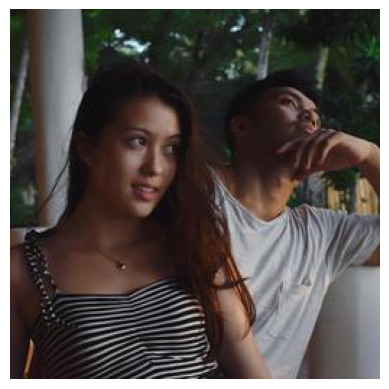

In [204]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

def show_random_image(df):
    # pick a random row
    row = df.sample(1).iloc[0]

    # pick a random image from that post
    img_path = random.choice(row["image_path"])

    image = mpimg.imread(img_path)
    plt.imshow(image)
    plt.axis("off")

show_random_image(df)

### Make this dataframe match the previous one from the other dataset

In [209]:
df = df.rename(columns={"followees": "following"})

### Convert datatype for followers and following

In [210]:
df["followers"] = pd.to_numeric(df["followers"], errors="coerce").astype("Int64")
df["following"] = pd.to_numeric(df["following"], errors="coerce").astype("Int64")


### Calculate engagement rate

In [211]:
# engagement_rate = (likes + comments) / max(followers, 1) # avoid division by 0
df["engagement_rate"] = (df["likes"] + df["comments"]) / df["followers"].clip(lower=1) # clip is max(followers, 1)


### Check missing info from influencers.txt

In [213]:
df[df["followers"].isna()].sample(10)


,user_id,username,publish_timestamp,has_location,is_carousel,num_images,is_sponsored,image_path,caption,likes,comments,followers,following,engagement_rate
54551,4570875828,avengersofmn,2018-12-03 22:17:08,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,“baby it’s cold outside ❄️” pro tip from the t...,918,121,<NA>,<NA>,<NA>
54560,4570875828,avengersofmn,2018-12-15 17:27:05,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,Nothing happier than a golden in snow during a...,784,0,<NA>,<NA>,<NA>
76315,31860769,honeydvash,2017-06-10 23:45:43,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"🌸Let us dance in the sun, wearing wild flowers...",245,12,<NA>,<NA>,<NA>
10108,2518223474,ashleighamoroso,2018-12-16 17:08:41,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,it’s our first holiday with the little one and...,367,12,<NA>,<NA>,<NA>
76418,31860769,honeydvash,2018-04-14 14:44:46,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,Found these beauties while walking through an ...,65,2,<NA>,<NA>,<NA>
24927,3221633325,herdingblake,2018-01-30 13:13:34,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,This morning i wrote my parents a letter. Do y...,634,200,<NA>,<NA>,<NA>
54374,4570875828,avengersofmn,2018-04-15 17:04:31,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,Sunday snowstorm boop! we can’t believe we are...,708,78,<NA>,<NA>,<NA>
7460,7738528,_andreabai,2016-11-21 18:09:33,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,Talking about what you need for the perfect ta...,253,69,<NA>,<NA>,<NA>
34704,3540219374,hamzahairdresser,2019-02-03 08:00:10,1,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,I'll take that PONYTAIL to go please...🤩🦄\n.\n...,92,6,<NA>,<NA>,<NA>
710,3758339054,amandamariegray,2017-11-11 03:34:43,0,0,1,0,[E:/instagram_dataset_raws/Instagram influence...,"🍂 And just as most of the leaves have changed,...",27,1,<NA>,<NA>,<NA>


#### Search for username in influencers.txt

In [ ]:
# Search for exact username
target_username = "amandamariegray"

influencers_file = os.path.join(directory, "influencers.txt")

with open(influencers_file, "r", encoding="utf-8") as f:
    for i, line in enumerate(f, 1):
        if line.startswith(target_username + "\t"):
            print(f"Found at line {i}:")
            print(line)
            break
    else:
        print("No matching line found")


No matching line found


These users are likely not in the influencers.txt. Since we can't make up the followers and following counts that directly form the target label, we will drop these rows.

In [216]:
df = df.dropna(subset=["followers"])


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98171 entries, 0 to 100913
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            98171 non-null  object 
 1   username           98171 non-null  object 
 2   publish_timestamp  98171 non-null  object 
 3   has_location       98171 non-null  int64  
 4   is_carousel        98171 non-null  int64  
 5   num_images         98171 non-null  int64  
 6   is_sponsored       98171 non-null  int64  
 7   image_path         98171 non-null  object 
 8   caption            98171 non-null  object 
 9   likes              98171 non-null  int64  
 10  comments           98171 non-null  int64  
 11  followers          98171 non-null  Int64  
 12  following          98171 non-null  Int64  
 13  engagement_rate    98171 non-null  Float64
dtypes: Float64(1), Int64(2), int64(6), object(5)
memory usage: 11.5+ MB
